In [1]:
from util.util import *
from util.param import *
from util.util import *
from util.util_montage import *

In [2]:
debug = False

In [4]:
# Hardcoded path for easier running
folder_path = "/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/data" # The data is stored here (.../condensate and .../RNA w/ ... being dataset subfolders)
img_path = "/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/result/img" # Images are saved here
result_path = "/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/result" # Calculation results are stored here

os.makedirs(img_path, exist_ok=True)

# Look up all subfolders in the data folder
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir() and not f.name.startswith('.')]
subfolders.sort()  # Sort the subfolders alphabetically

print(f"Found {len(subfolders)} subfolders in the data folder.")
i = 0
for subfolder in subfolders:
    print(f"    {i}: {subfolder.split('/')[-1]}")
    i += 1

Found 10 subfolders in the data folder.
    0: 2x_4EGI1
    1: 2x_CHX
    2: 2x_Har
    3: 2x_puro
    4: THOR_1x
    5: THOR_2x
    6: THORdel_2x
    7: THORdelta_1x
    8: mRNA-1x
    9: mRNA_2x


In [5]:
# Change this index to select different subfolders
index = 9
legend_bool = True
overwrite_trace_output = False

data_path = subfolders[index]
data_name = data_path.split("/")[-1]
print(f"Selected data for {data_name} in folder: {data_path}")

Selected data for mRNA_2x in folder: /Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/data/mRNA_2x


In [6]:
file_pairs = find_matching_files(data_path)

if not file_pairs:
    if debug:
        print("❌ No matching file pairs found!")
    pass
else:
    if debug:
        print(f"📂 Loading {len(file_pairs)} experiment datasets...")
    
    all_tracks = []
    all_condensates = []
    
    for rna_path, condensate_path, exp_name in track(file_pairs, description="Loading datasets"):
        df_tracks, df_condensates = load_dataset_pair(rna_path, condensate_path, exp_name)
        
        if df_tracks is not None and df_condensates is not None:
            all_tracks.append(df_tracks)
            all_condensates.append(df_condensates)
    
    if all_tracks and all_condensates:
        # Combine all datasets
        df_tracks_combined = pd.concat(all_tracks, ignore_index=True)
        df_condensates_combined = pd.concat(all_condensates, ignore_index=True)

        if debug:
            print(f"✅ Successfully loaded and combined:")
            print(f"   - {len(df_tracks_combined)} total track points")
            print(f"   - {len(df_condensates_combined)} total condensate entries")
            print(f"   - {df_tracks_combined['experiment'].nunique()} experiments")

        # Display summary statistics
        if debug:
            print("\n📊 Dataset Summary:")
        for exp in df_tracks_combined['experiment'].unique():
            exp_tracks = df_tracks_combined[df_tracks_combined['experiment'] == exp]
            exp_condensates = df_condensates_combined[df_condensates_combined['experiment'] == exp]
            if debug:
                print(f"   {exp}: {exp_tracks['trackID'].nunique()} tracks, "
                      f"{len(exp_condensates)} condensate entries")
    else:
        if debug:
            print("❌ No valid datasets were loaded successfully")
        pass

if debug:
    print("\n🎉 Data loading complete!")

Output()

In [7]:
df_condensates_combined

,frame,condensateID,contour_coord,center_x_pxl,center_y_pxl,area_um2,R_nm,mean_intensity,max_intensity,max_location,aspect_ratio,contour_solidity,contour_extent,experiment
0,0,1,"[[55, 603], [54, 604], [54, 605], [54, 606], [...",55.761905,606.345238,0.383292,349.293047,536.666667,755.0,"(57, 606)",1.000000,0.848485,0.437500,20220508-FLmRNA_2x_FOV-17
1,0,2,"[[30, 603], [30, 604], [29, 605], [30, 606], [...",31.456790,604.938272,0.184802,242.536893,478.238095,573.0,"(31, 604)",1.200000,0.900000,0.450000,20220508-FLmRNA_2x_FOV-17
2,0,3,"[[8, 603], [7, 604], [6, 605], [6, 606], [6, 6...",8.071429,605.357143,0.191646,246.987482,453.857143,535.0,"(8, 606)",0.833333,0.965517,0.466667,20220508-FLmRNA_2x_FOV-17
3,0,4,"[[24, 602], [24, 603], [24, 604], [25, 604], [...",25.000000,603.000000,0.054756,132.020363,463.000000,499.0,"(25, 603)",1.000000,1.000000,0.444444,20220508-FLmRNA_2x_FOV-17
4,0,5,"[[79, 601], [78, 602], [78, 603], [78, 604], [...",80.473684,603.122807,0.260091,287.731709,490.592593,606.0,"(81, 603)",1.000000,0.974359,0.527778,20220508-FLmRNA_2x_FOV-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152490,199,745,"[[100, 8], [99, 9], [100, 10], [99, 11], [98, ...",95.015873,16.579365,0.574938,427.794868,468.923077,557.0,"(96, 15)",0.800000,0.567568,0.233333,20220508-FLmRNA_2x_FOV-17
152491,199,746,"[[86, 6], [85, 7], [85, 8], [85, 9], [86, 10],...",87.111111,8.343434,0.225868,268.134624,457.583333,525.0,"(87, 8)",0.833333,1.000000,0.550000,20220508-FLmRNA_2x_FOV-17
152492,199,747,"[[17, 3], [16, 4], [16, 5], [17, 6], [18, 7], ...",18.146667,4.853333,0.171113,233.381234,442.789474,470.0,"(18, 4)",1.000000,1.000000,0.500000,20220508-FLmRNA_2x_FOV-17
152493,199,748,"[[114, 2], [114, 3], [114, 4], [113, 5], [113,...",115.690476,5.380952,0.287469,302.496652,505.656250,704.0,"(116, 5)",1.000000,0.700000,0.428571,20220508-FLmRNA_2x_FOV-17


In [55]:
shapely_poly_list = []
circularity_list = []
for idx, row in df_condensates_combined.iterrows():
    contour_coord = row['contour_coord']
    bx, by = parse_contour_string(contour_coord)
    shapely_poly = Polygon(zip(bx, by))
    shapely_poly_list.append(shapely_poly)

    area = shapely_poly.area
    perimeter = shapely_poly.length
    if perimeter == 0:
        circularity = 0
    else:
        circularity = 4 * np.pi * area / (perimeter ** 2)
    circularity_list.append(circularity)
    
df_condensates_combined['shapely_poly'] = shapely_poly_list
df_condensates_combined['circularity'] = circularity_list

In [56]:
df_condensates_combined

,frame,condensateID,contour_coord,center_x_pxl,center_y_pxl,area_um2,R_nm,mean_intensity,max_intensity,max_location,aspect_ratio,contour_solidity,contour_extent,experiment,shapely_poly,circularity
0,0,1,"[[55, 603], [54, 604], [54, 605], [54, 606], [...",55.761905,606.345238,0.383292,349.293047,536.666667,755.0,"(57, 606)",1.000000,0.848485,0.437500,20220508-FLmRNA_2x_FOV-17,"POLYGON ((55 603, 54 604, 54 605, 54 606, 54 6...",0.647359
1,0,2,"[[30, 603], [30, 604], [29, 605], [30, 606], [...",31.456790,604.938272,0.184802,242.536893,478.238095,573.0,"(31, 604)",1.200000,0.900000,0.450000,20220508-FLmRNA_2x_FOV-17,"POLYGON ((30 603, 30 604, 29 605, 30 606, 30 6...",0.746888
2,0,3,"[[8, 603], [7, 604], [6, 605], [6, 606], [6, 6...",8.071429,605.357143,0.191646,246.987482,453.857143,535.0,"(8, 606)",0.833333,0.965517,0.466667,20220508-FLmRNA_2x_FOV-17,"POLYGON ((8 603, 7 604, 6 605, 6 606, 6 607, 7...",0.838463
3,0,4,"[[24, 602], [24, 603], [24, 604], [25, 604], [...",25.000000,603.000000,0.054756,132.020363,463.000000,499.0,"(25, 603)",1.000000,1.000000,0.444444,20220508-FLmRNA_2x_FOV-17,"POLYGON ((24 602, 24 603, 24 604, 25 604, 26 6...",0.785398
4,0,5,"[[79, 601], [78, 602], [78, 603], [78, 604], [...",80.473684,603.122807,0.260091,287.731709,490.592593,606.0,"(81, 603)",1.000000,0.974359,0.527778,20220508-FLmRNA_2x_FOV-17,"POLYGON ((79 601, 78 602, 78 603, 78 604, 79 6...",0.878559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152490,199,745,"[[100, 8], [99, 9], [100, 10], [99, 11], [98, ...",95.015873,16.579365,0.574938,427.794868,468.923077,557.0,"(96, 15)",0.800000,0.567568,0.233333,20220508-FLmRNA_2x_FOV-17,"POLYGON ((100 8, 99 9, 100 10, 99 11, 98 11, 9...",0.193071
152491,199,746,"[[86, 6], [85, 7], [85, 8], [85, 9], [86, 10],...",87.111111,8.343434,0.225868,268.134624,457.583333,525.0,"(87, 8)",0.833333,1.000000,0.550000,20220508-FLmRNA_2x_FOV-17,"POLYGON ((86 6, 85 7, 85 8, 85 9, 86 10, 87 11...",0.912863
152492,199,747,"[[17, 3], [16, 4], [16, 5], [17, 6], [18, 7], ...",18.146667,4.853333,0.171113,233.381234,442.789474,470.0,"(18, 4)",1.000000,1.000000,0.500000,20220508-FLmRNA_2x_FOV-17,"POLYGON ((17 3, 16 4, 16 5, 17 6, 18 7, 19 7, ...",0.919386
152493,199,748,"[[114, 2], [114, 3], [114, 4], [113, 5], [113,...",115.690476,5.380952,0.287469,302.496652,505.656250,704.0,"(116, 5)",1.000000,0.700000,0.428571,20220508-FLmRNA_2x_FOV-17,"POLYGON ((114 2, 114 3, 114 4, 113 5, 113 6, 1...",0.452770


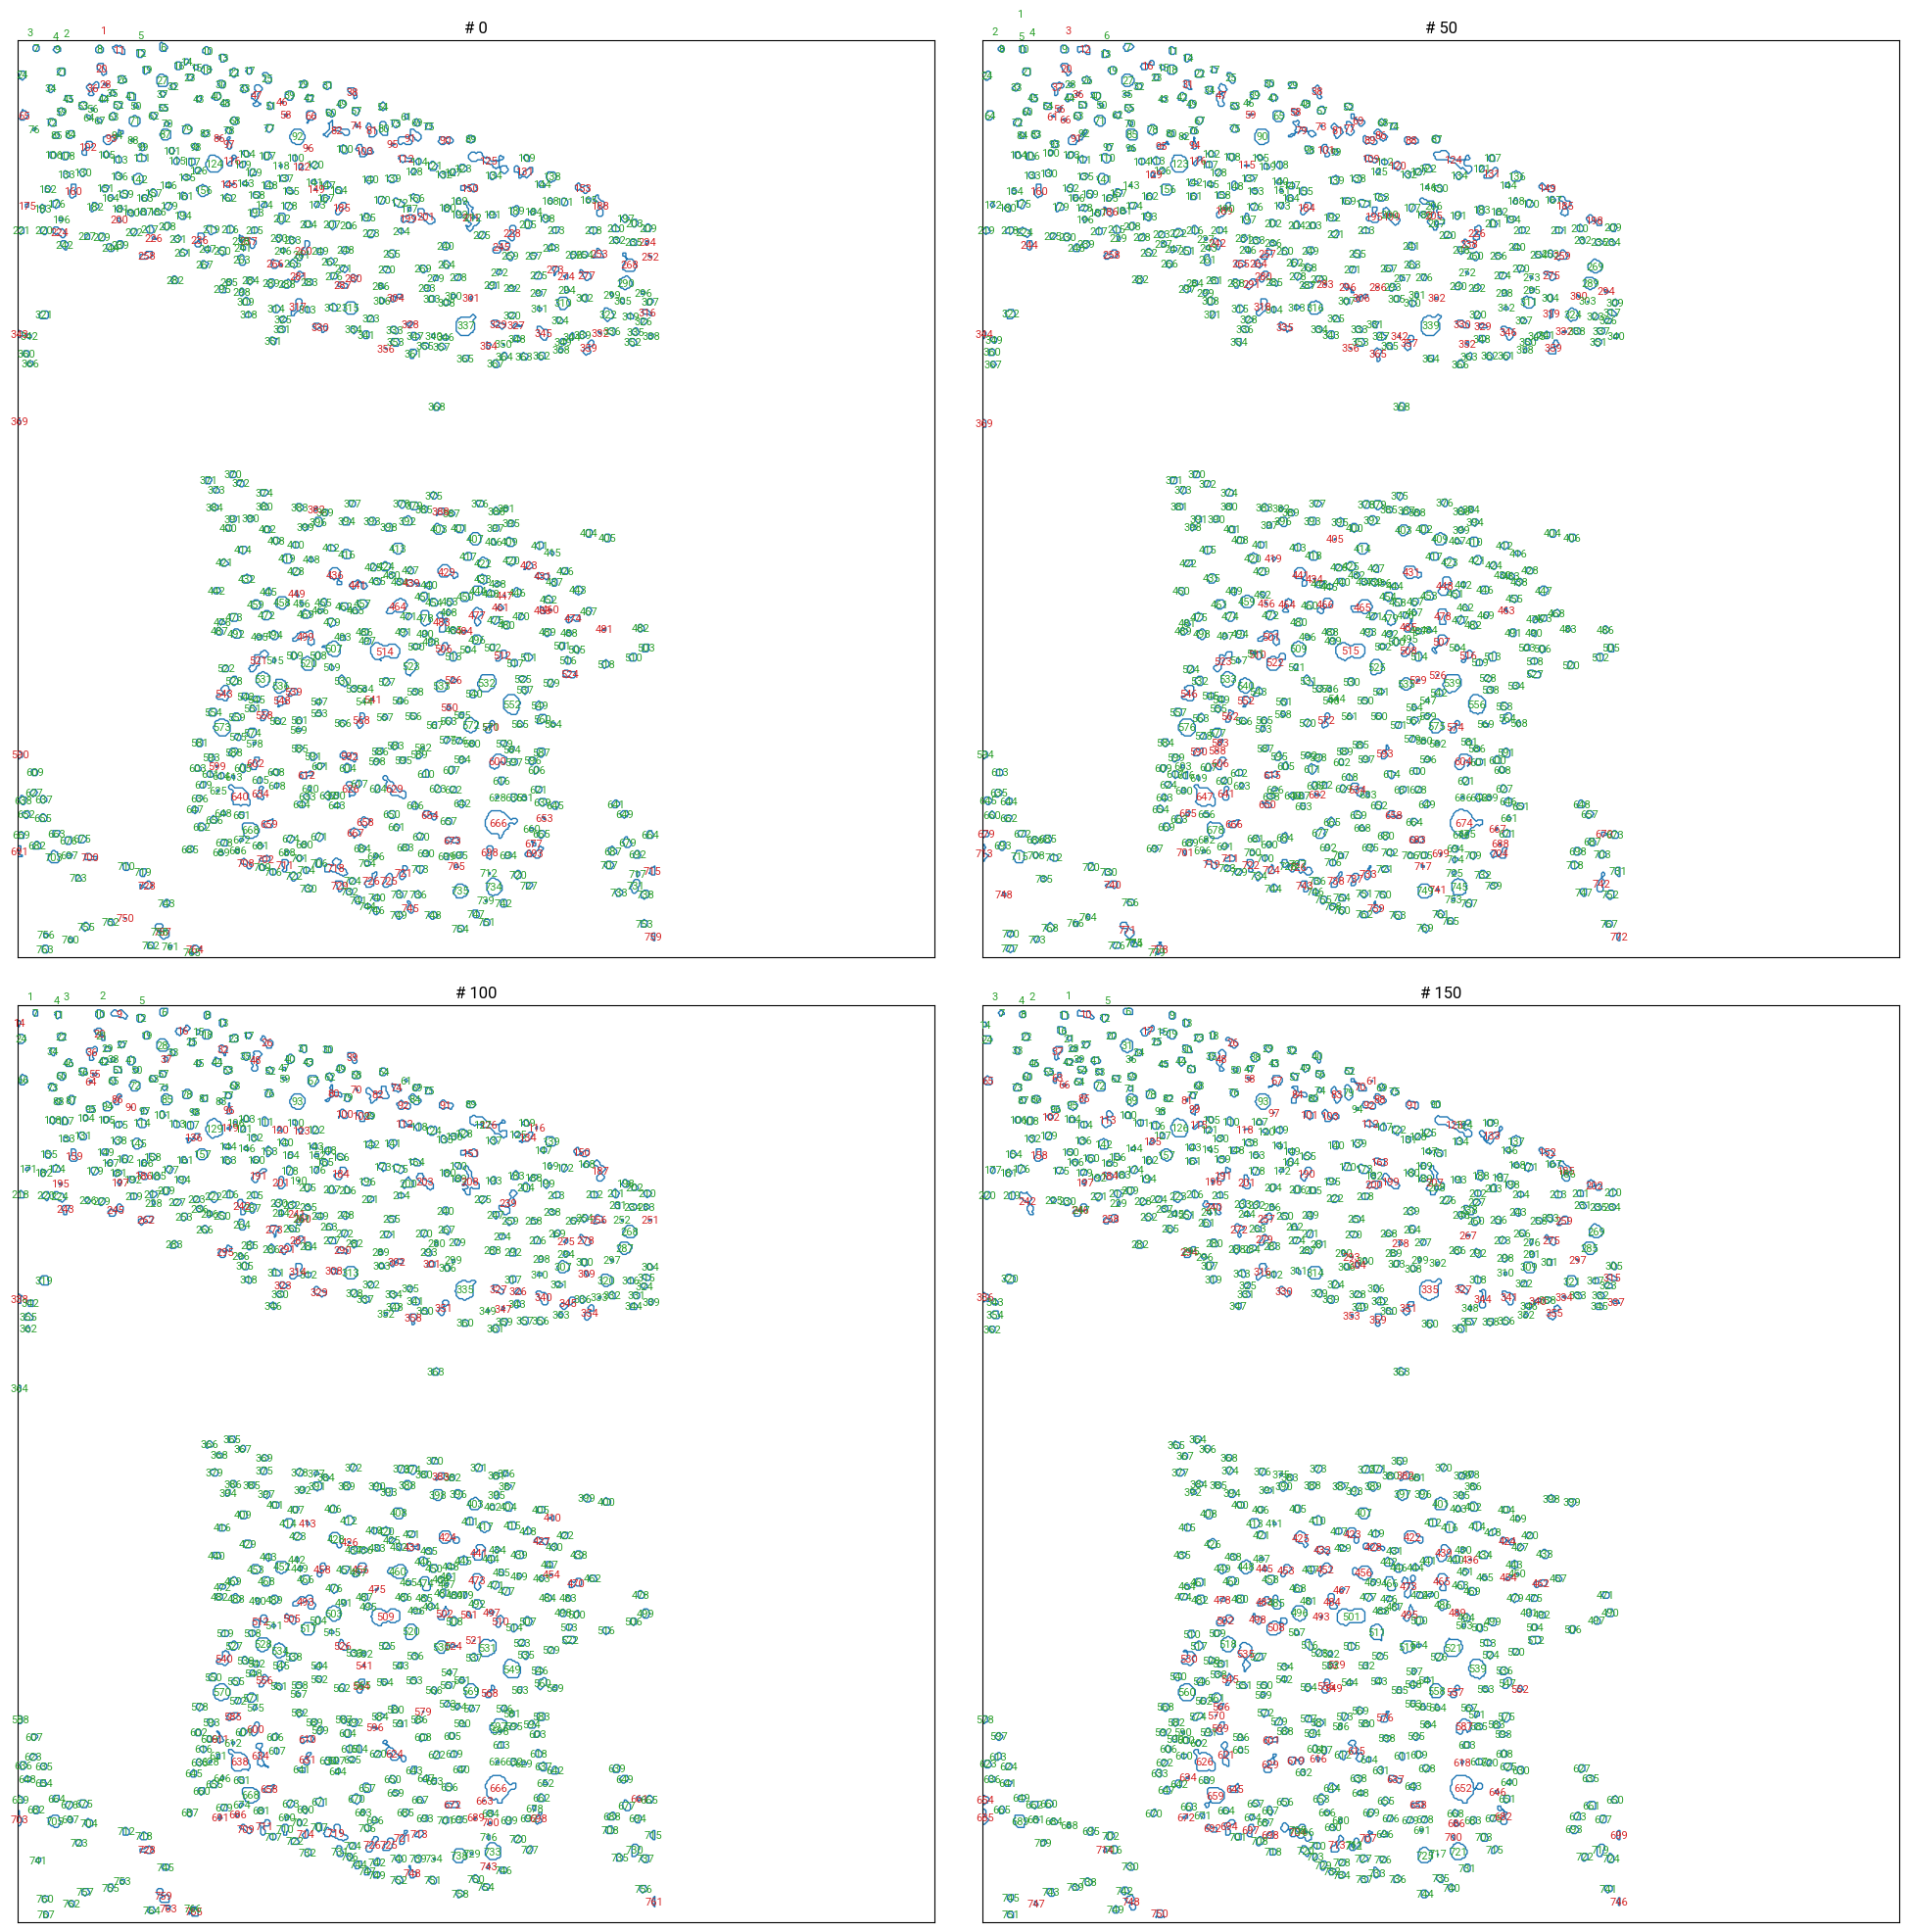

In [52]:
target_frames = [0, 50, 100, 150]
num_frames = len(target_frames)
# Calculate number of rows and columns for subplots so its a square
ncols = int(np.ceil(np.sqrt(num_frames)))
nrows = int(np.ceil(num_frames / ncols))

fig, ax = plt.subplots(nrows, ncols, figsize=(10 * ncols, 10 * nrows))

df_condensates_groupby_frames = df_condensates_combined.groupby('frame')

for frame in target_frames:
    ax_idx = target_frames.index(frame)
    row_idx = ax_idx // ncols
    col_idx = ax_idx % ncols
    ax_current = ax[row_idx, col_idx]
    
    # Filter condensates for the current frame
    df_frame = df_condensates_groupby_frames.get_group(frame)
    
    # Get the contour coords
    for _, row in df_frame.iterrows():
        contour_coords = row['contour_coord']
        bx, by = parse_contour_string(contour_coords)
        shapely_poly = Polygon(zip(bx, by))
        
        patch = MplPolygon(np.array(shapely_poly.exterior.coords), closed=True, fill=False, edgecolor='tab:blue', linewidth=1)
        ax_current.add_patch(patch)
        
        condensate_id = row['condensateID']
        # Label the condensate
        centroid = shapely_poly.centroid
        
        # Calculate circularity
        area = shapely_poly.area
        perimeter = shapely_poly.length
        if perimeter == 0:
            circularity = 0
        else:
            circularity = 4 * np.pi * area / (perimeter ** 2)
        
        if circularity < 0.7:
            ax_current.text(centroid.x, centroid.y, f'{condensate_id}', color='tab:red', fontsize=8, ha='center', va='center')
        else:
            ax_current.text(centroid.x, centroid.y, f'{condensate_id}', color='tab:green', fontsize=8, ha='center', va='center')
            
    ax_current.set_title(f'# {frame}', fontsize=12)
    ax_current.set_xlim(0, 600)  # Adjust limits as per your image size
    ax_current.set_ylim(0, 600)
    ax_current.set_aspect('equal')
    # Remove axis labels and ticks
    ax_current.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()

save_path = os.path.join(img_path, f"condensate_contour/{data_name}_{'_'.join(str(frame) for frame in target_frames)}.svg")
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=300, bbox_inches='tight', format='svg')
plt.show()